[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nisheshgogia/vorithm-interview-questions-solutions/blob/main/Python/sliding_window/sliding_window.ipynb)

# Sliding Window

# 1. Longest Substring with At Most K Distinct Characters

# Difficulty: 🟡 Medium

Problem Statement:
Given a string s and an integer k, return the length of the longest substring that contains at most k distinct characters.
```
Example 1:
Input: s = "eceba", k = 2
Output: 3
Explanation: Substring "ece" has 2
distinct characters (e and c)

```
```
Example 2:
Input: s = "aa", k = 1
Output: 2
Explanation: Entire string "aa" has 1 distinct character

```
```
Example 3:
Input: s = "abcdefg", k = 3
Output: 3
Explanation: "abc", "bcd", "cde", etc. have 3 distinct characters

In [ ]:
#Brute Force Approach (Check All Substrings)
def longest_substring_k_distinct_brute(s, k):
    max_len = 0
    n = len(s)

    for i in range(n):
        char_count = {}
        for j in range(i, n):
            # Add current character to window
            char_count[s[j]] = char_count.get(s[j], 0) + 1

            # Check if we have at most k distinct characters
            if len(char_count) <= k:
                max_len = max(max_len, j - i + 1)
            else:
                break  # More than k distinct, no point extending

    return max_len

print(longest_substring_k_distinct_brute("eceba", 2))  # Output: 3
print(longest_substring_k_distinct_brute("aa", 1))     # Output: 2

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : k=0 → breaks immediately, but still n start positions checked
# avg   → O(n^2) : outer loop n times, inner loop extends until k+1 distinct
#                  average: inner runs ~n/2 times
#                  total ≈ n × n/2 = O(n^2)
# worst → O(n^2) : k=n → all characters distinct, inner always runs full length
#                  n start positions × n extensions = O(n^2)
# space → O(k)   : char_count dict stores at most k+1 distinct characters

#best time complexity    - O(n)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(k)


3
2


In [ ]:
#Optimized Approach (Sliding Window with HashMap)
def longest_substring_k_distinct_optimized(s, k):
    if k == 0 or not s:
        return 0

    left = 0
    max_len = 0
    char_count = {}

    for right in range(len(s)):
        # Expand window: add right character
        char_count[s[right]] = char_count.get(s[right], 0) + 1

        # Shrink window while we have more than k distinct characters
        while len(char_count) > k:
            char_count[s[left]] -= 1
            if char_count[s[left]] == 0:
                del char_count[s[left]]
            left += 1

        # Update max length
        max_len = max(max_len, right - left + 1)

    return max_len

print(longest_substring_k_distinct_optimized("eceba", 2))  # Output: 3
print(longest_substring_k_distinct_optimized("aa", 1))     # Output: 2

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : k >= all distinct chars in s → window never shrinks
#                  right moves n times, left never moves
# avg   → O(n)   : right pointer moves n times (each element added once)
#                  left pointer moves at most n times (each element removed once)
#                  total pointer movements = 2n = O(n)
# worst → O(n)   : k=0 or k=1 with all different chars → left catches up
#                  but still: right moves n, left moves n → 2n = O(n)
# space → O(k)   : char_count stores at most k+1 characters (briefly)

# KEY INSIGHT: Each character added once (right++) and removed once (left++)
# Total operations = 2n = O(n)

# VISUALIZATION for s="eceba", k=2:
# Step 1: right=0, s[0]='e', count={'e':1}, len=1, max=1
# Step 2: right=1, s[1]='c', count={'e':1,'c':1}, len=2, max=2
# Step 3: right=2, s[2]='e', count={'e':2,'c':1}, len=3, max=3
# Step 4: right=3, s[3]='b', count={'e':2,'c':1,'b':1}, len>k=2
#         Shrink: left=0→1→2, count={'e':1,'b':1}, len=2
# Step 5: right=4, s[4]='a', count={'e':1,'b':1,'a':1}, len>k
#         Shrink: left=2→3, count={'b':1,'a':1}, len=2
# Result: max=3 ✓

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(k)


3
2


## 2. Container With Most Water
**Difficulty: 🟡 Medium**

**Problem Statement:**
You are given an integer array height of length n. There are n vertical lines drawn such that the two endpoints of the i-th line are (i, 0) and (i, height[i]).

Find two lines that together with the x-axis form a container, such that the container contains the most water.

Return the maximum amount of water a container can store.

**Note:** You may not slant the container.

**Example 1:**
```
Input: height = [1,8,6,2,5,4,8,3,7]
Output: 49
Explanation:
Lines at index 1 (height=8) and index 8 (height=7)
Width = 8 - 1 = 7
Height = min(8, 7) = 7
Area = 7 × 7 = 49
```

**Example 2:**
```
Input: height = [1,1]
Output: 1
```

**Example 3:**
```
Input: height = [4,3,2,1,4]
Output: 16
Explanation: Lines at indices 0 and 4, area = 4 × min(4,4) = 16

In [ ]:
#Brute Force Approach (Check All Pairs)
def max_area_brute(height):
    max_water = 0
    n = len(height)

    for i in range(n):
        for j in range(i + 1, n):
            # Width between lines i and j
            width = j - i
            # Height is limited by shorter line
            h = min(height[i], height[j])
            # Area = width × height
            area = width * h
            max_water = max(max_water, area)

    return max_water

print(max_area_brute([1,8,6,2,5,4,8,3,7]))  # Output: 49
print(max_area_brute([1,1]))                # Output: 1

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n^2) : no early exit possible, must check all pairs
#                  even if max found early, can't know without checking
# avg   → O(n^2) : outer loop n times, inner loop n-i times
#                  total pairs = n(n-1)/2 = O(n^2)
# worst → O(n^2) : all pairs must be checked
#                  n + (n-1) + (n-2) + ... + 1 = n(n+1)/2 = O(n^2)
# space → O(1)   : only max_water and loop variables

#best time complexity    - O(n^2)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(1)

49
1


In [ ]:
#Optimized Approach (Two Pointers from Both Ends)
def max_area_optimized(height):
    left = 0
    right = len(height) - 1
    max_water = 0

    while left < right:
        # Calculate area with current pair
        width = right - left
        h = min(height[left], height[right])
        area = width * h
        max_water = max(max_water, area)

        # Move pointer with shorter height (greedy)
        # Moving taller pointer can only decrease area
        if height[left] < height[right]:
            left += 1
        else:
            right -= 1

    return max_water

print(max_area_optimized([1,8,6,2,5,4,8,3,7]))  # Output: 49
print(max_area_optimized([1,1]))                # Output: 1

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : even if max found immediately, must check all positions
#                  pointers start at ends and meet in middle
# avg   → O(n)   : left and right move toward each other
#                  total steps = n (they meet after ~n/2 steps each)
# worst → O(n)   : left and right traverse full array once
#                  total pointer movements ≤ n
# space → O(1)   : only left, right, max_water variables

# WHY IT WORKS (Greedy Two Pointers):
# Key insight: Area = width × min(height[left], height[right])
# - Width decreases as pointers move inward
# - To potentially increase area, we need greater height
# - Moving the shorter line might find a taller line
# - Moving the taller line can only make area smaller (width↓, height↓ or same)

# VISUALIZATION for [1,8,6,2,5,4,8,3,7]:
# Initial: left=0(h=1), right=8(h=7), area=8×1=8
# Move left (shorter): left=1(h=8), right=8(h=7), area=7×7=49 ✓
# Move right (shorter): left=1(h=8), right=7(h=3), area=6×3=18
# ...continue until left meets right
# Max: 49

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)


49
1


## 3. Trapping Rain Water
**Difficulty: 🔴 Hard**

**Problem Statement:**
Given n non-negative integers representing an elevation map where the width of each bar is 1, compute how much water it can trap after raining.

**Example 1:**
```
Input: height = [0,1,0,2,1,0,1,3,2,1,2,1]
Output: 6
Explanation:
Elevation map: (| = wall, ~ = water)
    |
    |  ~ ~ |
    | ~| ~ || ~|
_|_||_|_|||_||_
0 1 0 2 1 0 1 3 2 1 2 1

Water trapped: 1 + 1 + 2 + 1 + 1 = 6
```

**Example 2:**
```
Input: height = [4,2,0,3,2,5]
Output: 9

In [ ]:
#Brute Force Approach (For Each Position, Find Left and Right Max)
def trap_water_brute(height):
    if not height:
        return 0

    n = len(height)
    water = 0

    for i in range(n):
        # Find max height to the left of i
        left_max = 0
        for j in range(i):
            left_max = max(left_max, height[j])

        # Find max height to the right of i
        right_max = 0
        for j in range(i + 1, n):
            right_max = max(right_max, height[j])

        # Water at position i = min(left_max, right_max) - height[i]
        # Only if this is positive
        water_at_i = max(0, min(left_max, right_max) - height[i])
        water += water_at_i

    return water

print(trap_water_brute([0,1,0,2,1,0,1,3,2,1,2,1]))  # Output: 6
print(trap_water_brute([4,2,0,3,2,5]))              # Output: 9

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n^2) : no early exit, must compute left_max and right_max for each i
# avg   → O(n^2) : outer loop n times
#                  for each i: left scan O(i) + right scan O(n-i) ≈ O(n)
#                  total = n × O(n) = O(n^2)
# worst → O(n^2) : all positions checked, each with O(n) scans
# space → O(1)   : only water, left_max, right_max variables

#best time complexity    - O(n^2)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(1)

6
9


In [ ]:
#Optimized Approach 1 (Precompute Left and Right Max Arrays)
def trap_water_arrays(height):
    if not height:
        return 0

    n = len(height)

    # Precompute left max for each position
    left_max = [0] * n
    left_max[0] = height[0]
    for i in range(1, n):
        left_max[i] = max(left_max[i-1], height[i])

    # Precompute right max for each position
    right_max = [0] * n
    right_max[n-1] = height[n-1]
    for i in range(n-2, -1, -1):
        right_max[i] = max(right_max[i+1], height[i])

    # Calculate water at each position
    water = 0
    for i in range(n):
        water += min(left_max[i], right_max[i]) - height[i]

    return water

print(trap_water_arrays([0,1,0,2,1,0,1,3,2,1,2,1]))  # Output: 6

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : three separate O(n) passes (left, right, calculate)
# avg   → O(n)   : left_max computation: O(n)
#                  right_max computation: O(n)
#                  water calculation: O(n)
#                  total = 3n = O(n)
# worst → O(n)   : same three passes regardless of input
# space → O(n)   : left_max and right_max arrays each size n

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(n)


6


In [ ]:
#Optimized Approach 2 (Two Pointers - Best Space Efficiency)
def trap_water_optimized(height):
    if not height:
        return 0

    left = 0
    right = len(height) - 1
    left_max = 0
    right_max = 0
    water = 0

    while left < right:
        if height[left] < height[right]:
            # Process left side
            if height[left] >= left_max:
                left_max = height[left]
            else:
                water += left_max - height[left]
            left += 1
        else:
            # Process right side
            if height[right] >= right_max:
                right_max = height[right]
            else:
                water += right_max - height[right]
            right -= 1

    return water

print(trap_water_optimized([0,1,0,2,1,0,1,3,2,1,2,1]))  # Output: 6
print(trap_water_optimized([4,2,0,3,2,5]))              # Output: 9

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : pointers start at ends and meet in middle
#                  each element processed exactly once
# avg   → O(n)   : left and right pointers together traverse all n elements
#                  total steps = n
# worst → O(n)   : all elements visited once by either left or right pointer
# space → O(1)   : only left, right, left_max, right_max, water variables

# WHY IT WORKS (Two Pointers):
# Key insight: Water trapped at position depends on min(left_max, right_max)
# - If height[left] < height[right], water at left is determined by left_max
#   (because right_max is at least height[right] which is already > left_max)
# - Process the side with shorter height, update max, calculate water
# - Move that pointer inward

# VISUALIZATION for [0,1,0,2,1,0,1,3,2,1,2,1]:
# left=0, right=11, h[0]=0<h[11]=1, left_max=0, no water, left=1
# left=1, right=11, h[1]=1=h[11]=1, left_max=1, no water, left=2
# left=2, right=11, h[2]=0<h[11]=1, water+=(1-0)=1, left=3
# ...continue...
# Total: 6

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)

6
9


## 4. Minimum Size Subarray Sum
**Difficulty: 🟡 Medium**

**Problem Statement:**
Given an array of positive integers nums and a positive integer target, return the minimal length of a contiguous subarray whose sum is greater than or equal to target. If there is no such subarray, return 0 instead.

**Example 1:**
```
Input: target = 7, nums = [2,3,1,2,4,3]
Output: 2
Explanation: Subarray [4,3] has minimal length (sum = 7 ≥ 7)
```

**Example 2:**
```
Input: target = 4, nums = [1,4,4]
Output: 1
Explanation: Subarray [4] has minimal length
```

**Example 3:**
```
Input: target = 11, nums = [1,1,1,1,1,1,1,1]
Output: 0
Explanation: No subarray sums to 11

In [ ]:
#Brute Force Approach (Check All Subarrays)
def min_subarray_len_brute(target, nums):
    n = len(nums)
    min_len = float('inf')

    for i in range(n):
        current_sum = 0
        for j in range(i, n):
            current_sum += nums[j]

            if current_sum >= target:
                min_len = min(min_len, j - i + 1)
                break  # No need to extend further from i

    return 0 if min_len == float('inf') else min_len

print(min_subarray_len_brute(7, [2,3,1,2,4,3]))  # Output: 2
print(min_subarray_len_brute(4, [1,4,4]))        # Output: 1
print(min_subarray_len_brute(11, [1,1,1,1,1,1,1,1]))  # Output: 0

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : all elements equal target → inner breaks immediately each time
#                  n outer iterations × 1 inner = O(n)
# avg   → O(n^2) : target found at average distance ~n/2 from each start
#                  n start positions × n/2 extensions = O(n^2)
# worst → O(n^2) : target very large or no valid subarray
#                  all n start positions × all n extensions = O(n^2)
# space → O(1)   : only min_len and current_sum variables

#best time complexity    - O(n)
#average time complexity - O(n^2)
#worst time complexity   - O(n^2)
#space complexity        - O(1)

2
1
0


In [ ]:
#Optimized Approach (Sliding Window with Two Pointers)
def min_subarray_len_optimized(target, nums):
    n = len(nums)
    left = 0
    current_sum = 0
    min_len = float('inf')

    for right in range(n):
        # Expand window: add right element
        current_sum += nums[right]

        # Shrink window while sum >= target
        while current_sum >= target:
            min_len = min(min_len, right - left + 1)
            current_sum -= nums[left]
            left += 1

    return 0 if min_len == float('inf') else min_len

print(min_subarray_len_optimized(7, [2,3,1,2,4,3]))  # Output: 2
print(min_subarray_len_optimized(4, [1,4,4]))        # Output: 1
print(min_subarray_len_optimized(11, [1,1,1,1,1,1,1,1]))  # Output: 0

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : even if target met immediately, right still moves n times
# avg   → O(n)   : right pointer moves n times (each element added once)
#                  left pointer moves at most n times (each element removed once)
#                  total operations = 2n = O(n)
# worst → O(n)   : large target or no valid subarray
#                  right moves n times, left stays at 0 or moves minimally
#                  still O(n) since right dominates
# space → O(1)   : only left, current_sum, min_len variables

# KEY INSIGHT: Sliding Window
# - Expand by moving right pointer (add elements)
# - Shrink by moving left pointer when condition met (remove elements)
# - Each element added once and removed at most once → O(2n) = O(n)

# VISUALIZATION for target=7, nums=[2,3,1,2,4,3]:
# right=0: sum=2, no shrink, len=∞
# right=1: sum=5, no shrink, len=∞
# right=2: sum=6, no shrink, len=∞
# right=3: sum=8≥7, shrink: left=0→1→2, sum=6→4→3, min=4
# right=4: sum=7≥7, shrink: left=2→3, sum=7→5, min=3
#          sum=5<7, stop shrinking
# right=5: sum=8≥7, shrink: left=3→4, sum=8→4, min=2 ✓
# Result: 2

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)

2
1
0


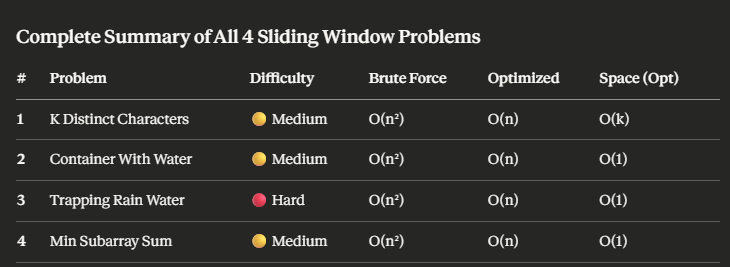